# Config

In [1]:
import time

_timers = {}

def timer_start(name="default"):
    _timers[name] = time.perf_counter()

def timer_end(name="default"):
    dt = time.perf_counter() - _timers.pop(name)
    print(f"[{name}] {dt:.2f}s")
    return dt
timer_start()

In [2]:
# Cell 0 — CONFIG
#case
case_name = "205_copper_05"
experiment = "ablation_01"

import json
from pathlib import Path
from pprint import pprint
import numpy as np
%load_ext autoreload
%autoreload 2
import sys, os
from dotenv import load_dotenv
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))  # only path this notebook sets; A_Config adds the rest on import
from A_Config import (
    set_case, case_dir, source_dir, query_dir, sam3_masks_dir,
    frames_for_cam_poses_dir, frames_for_recon_dir, vggt_o_output_dir,
    predictions_path, ply_dir, reg_dir, csv_path_gps, csv_path_pose,
    assets_dir, recon_for_MAP_dir,recon_for_EVENT_dir, agent_p_output_dir,
    set_pass, pass_num
)

print("project_root:", project_root)
print(project_root, project_root.exists())
load_dotenv(project_root / ".env")

set_case(case_name, experiment)

case_dir_ = case_dir()
source_dir_ = source_dir()
query_dir_ = query_dir()
masks_dir = sam3_masks_dir()
# These two are the PARENT stage folders. Each recon's own frame set now lives in a
# beat-keyed subfolder of them, handed out by build_recon_requests as job["frames_dir"].
frames_for_cam_poses = frames_for_cam_poses_dir()

frames_for_recon = frames_for_recon_dir()
VGGT_O_output_dir = vggt_o_output_dir()#used until 15 aug
ply_dir_ = ply_dir()
reg_dir_ = reg_dir()
csv_path_GPS = csv_path_gps()
csv_path_pose_ = csv_path_pose()

FRAME_NAME_FMT = "{:04d}.jpg"
# video loading
from Two2D.B_video_processing import video_fps
# Auto-find the video in 010_source
videos = list(source_dir_.glob("*.mp4"))
print(source_dir_)
assert len(videos) == 1, f"Expected 1 video, found {len(videos)}: {videos}"
video_path = videos[0]
print(f"Case    : {case_name}")
print(f"Video   : {video_path.name}")
fps = video_fps(video_path)
print(f"video fps: {fps:.3f}")
import cv2; total_frames = int(cv2.VideoCapture(str(video_path)).get(cv2.CAP_PROP_FRAME_COUNT))
print("total_frames",total_frames )
#reporting
from C_CSV_report import add_to_report
overview = {
    "Video_name"      : video_path.name, 
    "Title"      : f"{case_name}_{experiment}"
}
add_to_report(overview)
api_key = os.getenv("STREETVIEW_API_KEY")
restart =False




project_root: /workspace/project
/workspace/project True
/workspace/project/Data/205_copper_05/010_source
Case    : 205_copper_05
Video   : log_#2022-0002295_body_worn_camera_1_v1.mp4
video fps: 29.970
total_frames 5670


In [ ]:
#FLAGS dict and 'producer dict
flags = {
    "VID_TO_TEXT": True,
    "TRACKING": False,
    "FRAME_SELECTION": True,
    "RECON_CAM_POSES": False,
    "RECON_3D": False,
    "GOOGLE_MAP": False,
    "BEV_MAP" : False,
    "PROJECTION": False,
    "MAKE_MOVIE": False,
    "MAKE_MOVIE_CUTS" : False,
    "MASK_OVERLAYS": False ,
    "PHYSICS_OVERLAYS" : False,
    "MULTICAM" : False
}
MENU_KEYS = {"TRACKING","RECON_CAM_POSES", "RECON_3D",
                          "GOOGLE_MAP", "BEV_MAP" , "PROJECTION", "MASK_OVERLAYS", "MULTICAM"}
producer_flags = {k: v for k, v in flags.items() if k in MENU_KEYS}

#2d ANALYSIS - JUST GPS now!
from D_2d_analysis import analysis_2D
analysis_2d_for_decisions = analysis_2D(video_path,  api_key)
print(analysis_2d_for_decisions)

{'GPS_signal': 'no'}


# AI First Pass
## Gem, vid to text

## Producer 1

In [4]:
# Bump this each time you hand the Producer feedback -- every paper-edit /
# draft file written after that gets "-{PASS}" on its name (see run_producer_agent
# / paper_edit_path), so passes accumulate on disk instead of overwriting.
PASS = 1
set_pass(PASS)

In [5]:
Question = "Make a video summary of this video"

In [7]:
if restart == False:
    #PRODUCER DRAFT 1
    from claude_agent.producer_agent_execution import run_producer_agent, build_producer_prompt_draft1
    prompt = build_producer_prompt_draft1(Question, analysis_2d_for_decisions, producer_flags)
    paper_edit_json_path = run_producer_agent(prompt, mode ="draft")


[16:15:33 +  0.00s] run_producer_agent: start
[16:15:33 +  0.00s] thread: start
[16:15:33 +  0.00s] event loop: created
[16:15:33 +  0.02s] query: start
[16:15:39 +  6.26s] turn 1 usage (claude-opus-5): in=2 out=3 cache_write=13336 cache_read=0
[16:15:39 +  6.26s] turn 1 content blocks: ['ThinkingBlock']
[16:15:39 +  6.27s] thinking:
I see BEV_MAP is flagged true, but generating maps also requires RECON_CAM_POSES, and since I can request any flag I keep false, I'll stay conservative and request just what's needed. Now I'm putting together the JSON.
[16:16:01 + 27.53s] turn 2 usage (claude-opus-5): in=2 out=3 cache_write=13336 cache_read=0
[16:16:01 + 27.53s] turn 2 content blocks: ['ToolUseBlock']
[16:16:01 + 27.53s] tool call: Write (/workspace/project/Data/205_copper_05/012_agent_p_output/ablation_01/205_copper_05_paper_edit_draft.json)
[16:16:01 + 27.53s] write content:
{
  "case_name": "205_copper_05",
  "brief": "Make a video summary of this video",
  "beats": [
    {
      "arche

### restart

### restart

In [8]:
# DRAFT TIDY UP
# Re-run this cell on its own to regenerate the HTML/flags after editing and correct mistakes
import importlib
import json
import render_paper_edit
importlib.reload(render_paper_edit)
from render_paper_edit import render_and_save, derive_and_save_flags, paper_edit_path

if restart == True:
    #2d ANALYSIS - JUST GPS now!
    from D_2d_analysis import analysis_2D
    analysis_2d_for_decisions = analysis_2D(video_path,  api_key)
    print(analysis_2d_for_decisions)

try:
    paper_edit_json_path  # from run_producer_agent, if the kernel still has it
    print(paper_edit_json_path)
except NameError:
    paper_edit_json_path = paper_edit_path()

html_path = render_and_save(paper_edit_json_path)
print(f"\n=== Rendered HTML ===\n  {html_path}")

flags_path = derive_and_save_flags(
    paper_edit_json_path, producer_flags.keys(), fps=fps,
    gps_signal=analysis_2d_for_decisions.get("GPS_signal"),
)
producer_output_flags = json.loads(flags_path.read_text(encoding="utf-8"))
flags.update(producer_output_flags)  # Producer owns MENU_KEYS; the rest stay operator-set
print(f"\n=== Derived flags (from {flags_path.name}) ===")
print(json.dumps(producer_output_flags, indent=2))

/workspace/project/Data/205_copper_05/012_agent_p_output/ablation_01/205_copper_05_ablation_01_1_draft.json

=== Rendered HTML ===
  /workspace/project/Data/205_copper_05/012_agent_p_output/ablation_01/205_copper_05_ablation_01_1_draft.html

=== Derived flags (from 205_copper_05_ablation_01_1_draft_flags.json) ===
{
  "TRACKING": true,
  "RECON_CAM_POSES": true,
  "RECON_3D": false,
  "GOOGLE_MAP": false,
  "BEV_MAP": true,
  "PROJECTION": false,
  "MASK_OVERLAYS": false,
  "MULTICAM": false
}


# Tracking

In [9]:
# TRACKING SAM3 PIPELINE

if flags["TRACKING"]:
    print("using this paper edit" , paper_edit_json_path)
    from run_models.A_ROBOFLOW_SAM3 import track_subject_sam3
  
    analysis_2d_for_decisions.update (track_subject_sam3(video_path, paper_edit_json_path)) # add to the dict
    tracker = "SAM3"
    pprint(analysis_2d_for_decisions)
else:
    print("Cell disabled")

using this paper edit /workspace/project/Data/205_copper_05/012_agent_p_output/ablation_01/205_copper_05_ablation_01_1_draft.json


/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


here
accessing data
[{'subject': 'silver car', 'start_s': 114.0, 'end_s': 130.0, 'beat_ids': ['beat-05'], 'expected_count': 1}, {'subject': 'person', 'start_s': 114.0, 'end_s': 130.0, 'beat_ids': ['beat-05'], 'expected_count': 1}]
Tracking this list2 dict_keys(['silver car', 'person'])
initialising tracking (local SAM3)


/workspace/project/Models/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/vscode/.local/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO 2026-09-02 16:16:10,270 2406711 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-09-02 16:16:10,271 2406711 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-09-02 16:16:10,272 2406711 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-09-02 16:16:17,127 2406711 sam3

[local SAM3] model loaded in 10.6s
[silver_car] for beat-05 requested 114.0-130.0s -> keyframe-aligned start frame 3330


frame loading (OpenCV) [rank=0]: 100%|██████████| 569/569 [00:00<00:00, 666.01it/s]
INFO 2026-09-02 16:16:51,895 2406711 sam3_base_predictor.py: 146: started new session 75e8bc7d-0ba5-4268-80af-fe6f5a0ddb60
propagate_in_video: 100%|██████████| 569/569 [02:06<00:00,  4.50it/s]
INFO 2026-09-02 16:19:00,154 2406711 sam3_base_predictor.py: 305: propagation ended in session 75e8bc7d-0ba5-4268-80af-fe6f5a0ddb60
INFO 2026-09-02 16:19:00,391 2406711 sam3_base_predictor.py: 409: removed session 75e8bc7d-0ba5-4268-80af-fe6f5a0ddb60


[person] for beat-05 requested 114.0-130.0s -> keyframe-aligned start frame 3330


frame loading (OpenCV) [rank=0]: 100%|██████████| 569/569 [00:00<00:00, 607.15it/s]
INFO 2026-09-02 16:19:25,462 2406711 sam3_base_predictor.py: 146: started new session a9e927f0-784a-43fb-a285-0bac22bec208
propagate_in_video: 100%|██████████| 569/569 [02:53<00:00,  3.29it/s]
INFO 2026-09-02 16:22:18,977 2406711 sam3_base_predictor.py: 305: propagation ended in session a9e927f0-784a-43fb-a285-0bac22bec208
INFO 2026-09-02 16:22:19,289 2406711 sam3_base_predictor.py: 409: removed session a9e927f0-784a-43fb-a285-0bac22bec208


[local SAM3] released -- 0.01GiB still allocated
{'GPS_signal': 'no',
 'person-01': {'Subject_frames_present': [3330,
                                          3331,
                                          3332,
                                          3333,
                                          3334,
                                          3335,
                                          3336,
                                          3337,
                                          3338,
                                          3339,
                                          3340,
                                          3341,
                                          3342,
                                          3343,
                                          3344,
                                          3345,
                                          3346,
                                          3347,
                                          3348,
                  

In [10]:

%pprint

Pretty printing has been turned OFF


In [11]:
pprint(analysis_2d_for_decisions)

{'GPS_signal': 'no',
 'person-01': {'Subject_frames_present': [3330,
                                          3331,
                                          3332,
                                          3333,
                                          3334,
                                          3335,
                                          3336,
                                          3337,
                                          3338,
                                          3339,
                                          3340,
                                          3341,
                                          3342,
                                          3343,
                                          3344,
                                          3345,
                                          3346,
                                          3347,
                                          3348,
                                          3349,
                   

In [12]:
#TRACKING SAM3 MANUAL controls
manual_sam = False
if manual_sam == True:
    from run_models.A_ROBOFLOW_SAM3 import track_subject_sam3, run_sam3_manual
    analysis_2d_for_decisions.update (run_sam3_manual(video_path, "person")) # add to the dict
    tracker = "SAM3"
    print(analysis_2d_for_decisions)

## restart rebuild

In [13]:
#Rebuild tracking after restart 

if restart == True:
    from D_2d_analysis import analysis_2d_tracking_recovery, analysis_2d_gemvsSAM
    from render_paper_edit import paper_edit_path
    from pprint import pprint

    try:
        paper_edit_json_path  # from run_producer_agent, if the kernel still has it
    except NameError:
        paper_edit_json_path = paper_edit_path()

    #noun phrases form paper edit vs masks
    analysis_2d_for_decisions.update(analysis_2d_tracking_recovery(paper_edit_json_path))  # non-person subjects, from mask folders
    #Gemini people from paper edit  VS sam csv
    pprint(analysis_2d_for_decisions)

In [14]:
print(paper_edit_json_path)

/workspace/project/Data/205_copper_05/012_agent_p_output/ablation_01/205_copper_05_ablation_01_1_draft.json


## Re ID

In [15]:
#MATCHING GEM VS SAM
from A_Config import source_video_path
from Two2D.B_video_processing import video_dims
from Two2D.AX_gem_SAM_matcher import gem_person_targets_lookup
from Two2D.AY_claude_crop_matcher import write_masked_crops, match_tracks_to_descriptors
from D_2d_analysis import analysis_2d_gemvsSAM

_, _, fps = video_dims(source_video_path())

crops = write_masked_crops()                                  # eyeball these first
match_results = match_tracks_to_descriptors(paper_edit_json_path, crops_by_track=crops, fps=fps)

analysis_2d_for_decisions.update(analysis_2d_gemvsSAM(analysis_2d_for_decisions,
    gem_person_targets=gem_person_targets_lookup(paper_edit_json_path=paper_edit_json_path),         # beat_ids only
    match_results=match_results,                               # crops, not box IoU
))

[person-01] 10 crop(s) from 410 masked frames
[person-02] 5 crop(s) from 57 masked frames (5 under 1500px, skipped)
[person-03] 10 crop(s) from 17 masked frames
[person-04] 7 crop(s) from 133 masked frames (3 under 1500px, skipped)
[person-05] 9 crop(s) from 72 masked frames (1 under 1500px, skipped)
[person-06] 2 crop(s) from 2 masked frames
person-01 -> NONE
person-02 -> person-B
person-03 -> NONE (every person already on screen with it)
person-04 -> NONE
person-05 -> NONE
person-06 -> NONE
person-B (Police officer wearing a blue uniform shirt, a cap, and glasses, seen running with a gun and later standing near the police car.) -> [2]
5 track(s) matched nobody: person-01, person-03, person-04, person-05, person-06


In [16]:
pprint(analysis_2d_for_decisions)

{'GPS_signal': 'no',
 'person-01': {'Subject_frames_present': [3330,
                                          3331,
                                          3332,
                                          3333,
                                          3334,
                                          3335,
                                          3336,
                                          3337,
                                          3338,
                                          3339,
                                          3340,
                                          3341,
                                          3342,
                                          3343,
                                          3344,
                                          3345,
                                          3346,
                                          3347,
                                          3348,
                                          3349,
                   

In [17]:
#mask checker ALL IN ONE
# MAP beats (frames mode): masks exist only on the ~200 recon frames, spread over the
# whole window. video_overlay_edit would cut the SOURCE video first-to-last masked
# frame -- a 4-minute clip that's ~99% unmasked, plus it raises on _sam_id_shots.
# mask_check_map_beats builds the video from the recon frames instead, so every frame
# carries its mask. Zero-arg: resolves its own masks + recon frames, no cell order.
mask_check = False
if mask_check == True:
    from Two2D.W_video_editor import mask_check_map_beats
    for p in mask_check_map_beats():
        print(p)


In [18]:
#mask checker (overlays) - VID
mask_check = False
if mask_check ==True:
    
    print(masks_dir)
    from Two2D.W_video_editor import video_overlay_edit
    for i, mask in enumerate(p for p in masks_dir.iterdir() if p.is_dir()):
        video = video_overlay_edit(video_path, mask,  name = f"hidenseek_ms7_v1{mask.name}")
    

# RECON
## Frame Selection

## Restart

In [19]:
from render_paper_edit import build_recon_requests

recon_jobs = [j for j in build_recon_requests(paper_edit_json_path)
              if flags["RECON_CAM_POSES" if j["kind"] == "MAP" else "RECON_3D"]]

beat-05 MAP (RECON_CAM_POSES): 114-130s -> frames 3417-3896


In [20]:
#RECON JOBS - one per (beat, recon kind) the Producer asked for
# Every beat
# that asks for a recon gets its own: frame range,  frames folder and
# recon folder, so several MAP and several EVENT recons live side by side.
# Max one of each kind per beat -- two recons of a kind means two beats.
# Each job dict is added to by the cells below; nothing here binds a global `recon`.

def jobs_of(kind=None, archetype=None, flag=None, beat_key=None):
    """The lookup every cell below uses instead of a single global recon variable.

    kind      -- which SOLVE this is: "MAP" (RECON_CAM_POSES, the camera track a
                 map is built from) or "EVENT" (RECON_3D, a moment of action).
    archetype -- what the BEAT is for: "MAP" for a beat that renders a map.
    These two are not the same thing -- a non-MAP beat can ask for either solve --
    so map rendering selects on archetype and physics work selects on kind.
    flag      -- something in the beat's own requested_flags, e.g. "BEV_MAP"."""
    return [j for j in recon_jobs
            if (kind is None or j["kind"] == kind)
            and (archetype is None or j["archetype"] == archetype)
            and (flag is None or flag in (j["beat"].get("requested_flags") or []))
            and (beat_key is None or j["beat_key"] == beat_key)]

print(f"{len(recon_jobs)} recon job(s)")
for job in recon_jobs:
    print(f"  {job['beat_key']:<10} {job['kind']:<6} frames {job['start_frame']}-{job['end_frame']}"
          f"  -> {job['recon_dir']}")


1 recon job(s)
  beat-05    MAP    frames 3417-3896  -> /workspace/project/Data/205_copper_05/031_Recon_MAP/ablation_01/beat-05


In [21]:
#FRAME SELECTION - one frame set per recon job
# Same capacity/interval maths as v06, applied per job instead of once for the whole
# video: each beat's own window is thinned to `capacity` frames.
if flags["FRAME_SELECTION"] == True:
    from Two2D.B_video_processing import image_sequencer

    capacity  = 200      # frames one recon can hold
    window    = fps/2    # search window for sharpness
    min_sharp = 0.0      # raise this after inspecting selection_log.json

    for job in recon_jobs:
        span     = job["end_frame"] - job["start_frame"]
        skip     = (span + capacity - 1) // capacity     # frames to skip between samples
        interval = skip / fps                            # image_sequencer wants seconds
        print(f"{job['beat_key']} {job['kind']}: {span} frames, interval {skip}")

        results = image_sequencer(
            video_path    = str(video_path),
            output_dir    = str(job["frames_dir"]),
            interval_sec  = interval,
            search_window = window,
            min_sharpness = min_sharp,
            start_frame   = job["start_frame"],
            end_frame     = job["end_frame"],
        )
        print(f"  {len(results)} frames written to {job['frames_dir']}")
else:
    print("Cell disabled")


beat-05 MAP: 479 frames, interval 3
Window  : clamped from ±14.985014985014985 to ±1 (half interval)
Video   : log_#2022-0002295_body_worn_camera_1_v1.mp4
          30 fps · 5670 frames · 189.2s
Range   : frames 3417-3896 (479 frames)
Sampling: every 3 frames (0.10010000000000001s) → 160 candidates
Window  : ±1 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 479/479 [00:01<00:00, 413.17fr/s]


Selected: 160 frames  (20 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 479/479 [00:01<00:00, 430.94fr/s]

Log     : /workspace/project/Data/205_copper_05/020_frames_for_cam_poses/ablation_01/beat-05/selection_log.json
Sharpness (at 25% res): min 734 · mean 2228 · max 3295
  2 frames written to /workspace/project/Data/205_copper_05/020_frames_for_cam_poses/ablation_01/beat-05


In [22]:
print(frames_for_cam_poses_dir())

/workspace/project/Data/205_copper_05/020_frames_for_cam_poses/ablation_01


In [23]:
#MANUAL FRAME SELECTION - one frame set per recon job
manual_frames= False
if manual_frames == True:
    # Same capacity/interval maths as v06, applied per job instead of once for the whole
    # video: each beat's own window is thinned to `capacity` frames.

    from Two2D.B_video_processing import image_sequencer

    capacity  = 650      # frames one recon can hold
    window    = fps/2    # search window for sharpness
    min_sharp = 0.0      # raise this after inspecting selection_log.json

    span= 7581-0
    skip     = (span + capacity - 1) // capacity     # frames to skip between samples
    interval = skip / fps  
    output_dir    = str(frames_for_cam_poses_dir())
    results = image_sequencer(
    video_path    = str(video_path),
    output_dir    = output_dir,
    interval_sec  = interval,
    search_window = window,
    min_sharpness = min_sharp,
    start_frame   = 0,
    end_frame     = 7581,
    )
    print(output_dir)
else:
    print("Cell disabled")

Cell disabled


## VGGT OMEGA
### one solve per recon job

In [24]:
import torch, gc; gc.collect(); torch.cuda.empty_cache()

In [25]:
print(torch.cuda.memory_allocated()/2**30, torch.cuda.memory_reserved()/2**30)


0.0079345703125 0.01953125


In [26]:
import torch
print(torch.is_autocast_enabled())


False


In [27]:
#VGGT OMEGA - one solve per recon job
import gc, torch
gc.collect()
torch.cuda.empty_cache()
from run_models.E_VGGT_omega import run_vggt_omega

checkpoint = (project_root / "Models" / "vggt-omega" / "checkpoints"
              / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt")

# Several jobs means several full solves, so a re-run of this cell skips the ones
# already on disk rather than repeating every pass. Flip to True to force a re-solve.
rerun_existing = False

for job in recon_jobs:
    if not rerun_existing and (job["recon_dir"] / "predictions.npz").exists():
        print(f"skip {job['beat_key']} {job['kind']} -- predictions.npz already there")
        continue
    print(f"solving {job['beat_key']} {job['kind']} from {job['frames_dir']}")
    run_vggt_omega(
        image_dir        = str(job["frames_dir"]),
        output_dir       = job["recon_dir"],
        checkpoint_path  = str(checkpoint),
        vggt_omega_dir   = str(project_root / "Models" / "vggt-omega"),
        image_resolution = 512,
        conf_thres       = 20.0,
        max_points       = 0,
        show_cam         = True,
    )
    gc.collect()
    torch.cuda.empty_cache()


solving beat-05 MAP from /workspace/project/Data/205_copper_05/020_frames_for_cam_poses/ablation_01/beat-05
160 frames  →  /workspace/project/Data/205_copper_05/031_Recon_MAP/ablation_01/beat-05
GPU freed -- 1.70 GiB still allocated, 2.81 GiB reserved
Saved: /workspace/project/Data/205_copper_05/031_Recon_MAP/ablation_01/beat-05/predictions.npz
Saved: /workspace/project/Data/205_copper_05/031_Recon_MAP/ablation_01/beat-05/scene.glb


# POST RECON
## Processing

In [28]:
#LOAD VGGT_O recons for further processing - one per job
from Thr3D.F_post_recon_processing import Reconstruction, positions_to_frame_dict

def PRP(recon, frames):
    frame_keys = sorted(recon.frame_to_row, key=recon.frame_to_row.get)
    rows = [recon.frame_to_row[f] for f in frame_keys]
    extrinsic = recon.preds["extrinsic"][rows].cpu().numpy()   # (N,3,4) model-to-cam
    intrinsic = recon.preds["intrinsic"][rows].cpu().numpy()   # (N,3,3)
    R = extrinsic[:, :3, :3]
    t = extrinsic[:, :3, 3]
    cam_poses = -np.einsum("nji,nj->ni", R, t)  # cam centre in model space, per frame
    cam_poses_model_dict = positions_to_frame_dict(cam_poses, frames)
    return cam_poses_model_dict

# Each job loads its OWN predictions.npz from its own recon_dir -- v06 loaded the
# EVENT recon from the MAP folder.
for job in recon_jobs:
    job["recon"] = Reconstruction.load(
        job["frames_dir"], job["recon_dir"] / "predictions.npz", FRAME_NAME_FMT)
    job["cam_poses_model"] = PRP(job["recon"], job["frames_dir"])
    print(f"{job['beat_key']} {job['kind']}: {len(job['cam_poses_model'])} camera poses")


beat-05 MAP: 160 camera poses


In [29]:
#TRANSFORM CAMERA POSES VS GPS - per recon
# Every recon calibrates against GPS on its own: its own R/s/t and its own lat_0/lon_0
# origin. Everything lands in the same real-world frame, so lat/lons from different
# beats ARE comparable (unlike the raw model-space positions below).
# Source is anything but "RS_path" so the poses dict is used directly rather than being
# read as a RealityScan csv; the string doubles as the alignment chart's label.
if analysis_2d_for_decisions['GPS_signal'] == 'yes':
    from Q_Metric_georeferencing import model_to_GPS_calibrated_locations

    for job in recon_jobs:
        (job["cam_poses_real"], job["cam_latlons"], job["R_cw"], job["s_cw"],
         job["t_cw"], job["lat_0"], job["lon_0"]) = model_to_GPS_calibrated_locations(
            csv_path_GPS, job["cam_poses_model"], Source=f"VGGT_O {job['beat_key']}")
        print(f"{job['beat_key']}: {len(job['cam_latlons'])} lat/lons, "
              f"origin {job['lat_0']}, {job['lon_0']}")
else:
    print("Cell disabled")


Cell disabled


## Recon Visualisation

In [30]:
#Convert into model space and export into plys - one folder per recon
# Each recon's clouds go next to its own predictions.npz (recon_dir/ply) instead of a
# shared VGGT_O_output_dir/MAP|EVENT folder, so two beats can't overwrite each other.
# n.b. this translates to the beginning of the camera track solve, then re-translates
# to that recon's own cam 0 space.
for job in recon_jobs:
    ext = job["recon"].preds["extrinsic"][0].clone()
    job["ext"]     = ext            # this recon's cam0 view, reused by the BEV/projection cells
    job["ply_dir"] = job["recon_dir"] / "ply"
    _ = job["recon"].VGGT_O_preds_to_ply_export(job["ply_dir"],
                                                R=ext[:, 0:3],
                                                t=ext[:, 3],
                                                s=1)
    print(f"{job['beat_key']} {job['kind']} -> {job['ply_dir']}")


beat-05 MAP -> /workspace/project/Data/205_copper_05/031_Recon_MAP/ablation_01/beat-05/ply


In [31]:
# Cell — PLY visualisation, one per recon
import importlib
import F_cut3r_vis; importlib.reload(F_cut3r_vis)
from F_cut3r_vis import visualise_cut3r

for job in recon_jobs:
    print(f"{job['beat_key']} {job['kind']}: {job['recon_dir']}")
    visualise_cut3r(job["recon_dir"])


beat-05 MAP: /workspace/project/Data/205_copper_05/031_Recon_MAP/ablation_01/beat-05
Found 160 PLY files


╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

In [32]:
#cutr point cloud render
render_PC = False
if  flags["RECON_3D"] == True and render_PC == True:
    visualisation_dir = case_dir   /  CUT3R_output_dir 
    model = "CUT3R"
    ply_dir = visualisation_dir / "ply"
    basic_point_cloud_render(
        ply_dir, model     )
    # report metric name = render name, one row per output asset (path relative to
   

## ANALYSIS 3D

In [33]:
#depth confidence statistics - per recon
from C_CSV_report import add_to_report

for job in recon_jobs:
    conf = job["recon"].preds["depth_conf"].cpu().numpy()
    print(f"--- {job['beat_key']} {job['kind']} ---")
    print("min, max confidence", conf.min(), conf.max())
    print("frames, y, x", conf.shape)
    print("confidence percentiles", np.percentile(conf, [5, 25, 50, 75, 95]))

    # add_to_report rows are overwrite-by-key, so each recon's numbers carry its own
    # beat key -- otherwise only the last job's would survive in the CSV.
    tag = f"{job['beat_key']} {job['kind']}"
    add_to_report({
        f"Depth Confidence (min) [{tag}]"        : conf.min(),
        f"Depth Confidence (max) [{tag}]"        : conf.max(),
        f"Depth Confidence (mean) [{tag}]"       : conf.mean(),
        f"Depth Confidence percentiles [{tag}]"  : np.percentile(conf, [5, 25, 50, 75, 95]),
    })


--- beat-05 MAP ---
min, max confidence 1.0 8.563143
frames, y, x (160, 384, 688)
confidence percentiles [1.         1.00009429 1.03710037 1.24265599 2.05663636]


In [34]:
pprint(analysis_2d_for_decisions)

{'GPS_signal': 'no',
 'person-01': {'Subject_frames_present': [3330,
                                          3331,
                                          3332,
                                          3333,
                                          3334,
                                          3335,
                                          3336,
                                          3337,
                                          3338,
                                          3339,
                                          3340,
                                          3341,
                                          3342,
                                          3343,
                                          3344,
                                          3345,
                                          3346,
                                          3347,
                                          3348,
                                          3349,
                   

## subject 3d positions

In [70]:
#multi subject positioning - GPS or NOT now!
# Positions come out in each recon's OWN arbitrary model space (its own scale and
# origin), so they stay on the job. Two jobs' positions are not comparable and must
# not be merged -- only the GPS path below puts them in a shared frame.
# A subject whose masks never land in this recon's frames simply drops out of its dict.

from Q_subject_analysis import find_mask_centroids_in_model_space, subject_centroids_to_metric_and_gps_space
from Thr3D.G_transforms_alignments import  recon_to_recon_transform
from pathlib import Path
cv2.setLogLevel(0)
for job in recon_jobs:
    if analysis_2d_for_decisions['GPS_signal'] == "yes":
        R_mw, s_mw, t_mw = job["R_cw"], job["s_cw"], job["t_cw"]
       
    #then for any:
    subjects_positions = {}
    subjects_depth_std = {}
    subjects_confidence = {}
    subjects_real_pos = {}
    subjects_latlon   = {}
    subjects_confidence_gps = {}
    
    for subject_slug, entry in analysis_2d_for_decisions.items():
        if not isinstance(entry, dict) or not entry["Subject_frames_present"]:
            continue
        track_dirs = entry.get("masks_dirs") or [entry["masks_dir"]]
        merged_SAMS = {}
        merged_std  = {}
        merged_confidence = {}
        merged_real   = {}
        merged_latlon = []
        merged_confidence_gps = {}

        for track_dir in track_dirs:
            track_dir = Path(track_dir)
            centroids, frame_keys, depth_std_model, weight_sums_R = find_mask_centroids_in_model_space(
                job["recon"], masks_dir = track_dir, RA=15, analyse=False
            )
            for fk, c, s, w in zip(frame_keys, centroids, depth_std_model, weight_sums_R):
                if np.isfinite(np.asarray(c)).all(): #subject positions can be Nan
                    merged_SAMS[fk] = c
                    merged_std[fk]  = s
                    merged_confidence[fk] = w

            #GPS COMPONENT - 
            if analysis_2d_for_decisions['GPS_signal'] == "yes":
                sub_latlon, sub_pos, sub_pos_real_dict, sub_conf_dict = subject_centroids_to_metric_and_gps_space(
                    centroids, frame_keys, depth_std_model, weight_sums_R,
                    lat_0=job["lat_0"], lon_0=job["lon_0"],
                    R_mw=R_mw, s_mw=s_mw, t_mw=t_mw
)

                for fk, p in sub_pos_real_dict.items():
                                    if np.isfinite(np.asarray(p)).all():
                                        merged_real[fk] = p
                merged_confidence_gps.update(sub_conf_dict)
                merged_latlon += list(sub_latlon)

            
        if merged_SAMS:
            subjects_positions[subject_slug] = merged_SAMS
            subjects_depth_std[subject_slug] = merged_std
            subjects_confidence[subject_slug] = merged_confidence
        if merged_real:
            subjects_real_pos[subject_slug] = merged_real
            subjects_latlon[subject_slug]   = sorted(merged_latlon)
            subjects_confidence_gps[subject_slug] = merged_confidence_gps    
    job["subjects_positions"] = subjects_positions
    job["subjects_depth_std"] = subjects_depth_std
    job["subjects_confidence"] = subjects_confidence
    job["subjects_real_pos"] = subjects_real_pos
    job["subjects_latlon"]   = subjects_latlon
    job["subjects_confidence_GPS"] = subjects_confidence_gps
    print(f"{job['beat_key']} {job['kind']}: {list(subjects_positions)}")


/workspace/project/src/Q_subject_analysis.py:48: RuntimeWarning: invalid value encountered in divide
  (frame -> distance) that's computed internally on the way to the closest-approach
/workspace/project/src/Q_subject_analysis.py:52: RuntimeWarning: invalid value encountered in divide
  A_frames = np.array(sorted(A_real_dict.keys()))
/workspace/project/src/Q_subject_analysis.py:55: RuntimeWarning: invalid value encountered in divide
  B_frames = np.array(sorted(B_real_dict.keys()))


nan


/workspace/project/src/Q_subject_analysis.py:61: RuntimeWarning: invalid value encountered in divide
  matched_B_frames = B_frames[nearest_idx]


nan
nan
nan
118.7972378083372
nan
nan
nan
nan
nan
beat-05 MAP: ['silver_car-01', 'silver_car-02', 'silver_car-03', 'silver_car-04', 'person-01', 'person-03', 'person-04', 'person-05', 'person-B']


In [36]:
#for k, v in analysis_2d_for_decisions.items():
#    print(f"{k}: {v}")

for k, v in recon_jobs[0].items():
    print(f"{k}: {v}")

beat_key: beat-05
beat_ids: ['beat-05']
order: 5
archetype: MAP
kind: MAP
flag: RECON_CAM_POSES
start_frame: 3417
end_frame: 3896
frames_dir: /workspace/project/Data/205_copper_05/020_frames_for_cam_poses/ablation_01/beat-05
recon_dir: /workspace/project/Data/205_copper_05/031_Recon_MAP/ablation_01/beat-05
beat: {'archetype': 'MAP', 'order': 5, 'beat_id': ['beat-05'], 'segment_type': 'synthetic', 'duration_seconds': 8, 'source': None, 'start_frame': None, 'end_frame': None, 'lead_in_seconds': None, 'search_window_start_seconds': 114, 'search_window_end_seconds': 130, 'requested_flags': ['BEV_MAP', 'RECON_CAM_POSES', 'TRACKING'], 'quote': None, 'rationale': "GPS_signal is 'no', so a BEV map built from camera-pose recon is the only way to show the geometry of the stop and the shooting; window is continuous on-foot movement from vehicle exit to ground.", 'rejected_alternative': "GOOGLE_MAP — ruled out, 2D analysis reports GPS_signal 'no'.", 'flag': None, 'tracked_subject': ['silver car', 

In [37]:
for job in recon_jobs:
    print(f"--- {job['beat_key']} {job['kind']} ---")
    for k, v in job.get("subjects_positions", {}).items():
        print(f"{k}: {v}")


--- beat-05 MAP ---
silver_car-01: {3543: array([-0.23232718, -0.05127417,  0.29604261]), 3546: array([-0.17792911, -0.0496859 ,  0.31108518]), 3548: array([-0.16999105, -0.05841347,  0.31220888]), 3552: array([-0.1895619 , -0.05840788,  0.31585007]), 3556: array([-0.18699653, -0.05169684,  0.31051798]), 3558: array([-0.1950859 , -0.06195976,  0.31367358]), 3561: array([-0.18009053, -0.05272705,  0.30530464]), 3564: array([-0.18568256, -0.05550614,  0.30856194]), 3567: array([-0.17889245, -0.05827037,  0.31621333]), 3570: array([-0.1816442 , -0.05932747,  0.3018445 ]), 3573: array([-0.1796966 , -0.05279402,  0.30619059]), 3576: array([-0.16657807, -0.05070903,  0.290465  ]), 3579: array([-0.15543584, -0.04973398,  0.28873505]), 3582: array([-0.17564855, -0.05470978,  0.3033466 ]), 3585: array([-0.16210785, -0.05098698,  0.29479817]), 3588: array([-0.16956238, -0.05112252,  0.29666821]), 3591: array([-0.17747144, -0.05319483,  0.30408544]), 3594: array([-0.1923677 , -0.0551807 ,  0.2992

In [38]:
for job in recon_jobs:
    print(f"--- {job['beat_key']} {job['kind']} ---")
    pprint(job.get("subjects_real_pos") or job.get("subjects_positions"))


--- beat-05 MAP ---
{'person-01': {3417: array([-0.00353338,  0.00407316,  0.00967458]),
               3420: array([-0.01310745, -0.00628556,  0.04715961]),
               3423: array([ 0.00741622,  0.00865439, -0.05011446]),
               3426: array([ 0.01690077,  0.01723887, -0.07470584]),
               3429: array([ 0.00686174,  0.01562103, -0.06470349]),
               3432: array([ 0.00020003,  0.00406953, -0.02987631]),
               3435: array([ 0.02259898,  0.02569245, -0.1478763 ]),
               3438: array([ 0.00120618,  0.01773597, -0.11615147]),
               3441: array([ 0.01059738,  0.0258162 , -0.11628036]),
               3444: array([ 0.02452223,  0.03128613, -0.1626243 ]),
               3447: array([-0.01767217,  0.01831374, -0.13004184]),
               3450: array([-0.00796365,  0.00754939, -0.04768774]),
               3453: array([-0.02856102,  0.01740905, -0.08908193]),
               3456: array([-0.01063066, -0.00907845,  0.03951372]),
              

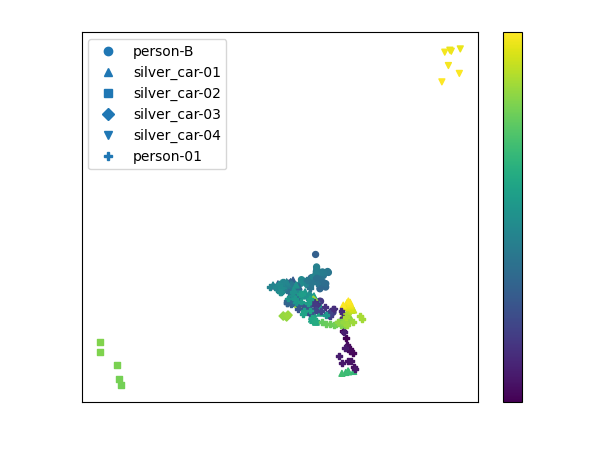

In [71]:
#graph postions 2d - NOT SURE HOW TO USE THIS! POINTLESS FOR THE REPORT!
# One figure per recon -- axes are that recon's own space, so plotting two on one set
# of axes would be meaningless.
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

markers = ["o", "^", "s", "D", "v", "P"]

for job in recon_jobs:
    subj = job.get("subjects_real_pos") or job.get("subjects_positions") or {}
    if not subj:
        print(f"{job['beat_key']} {job['kind']}: no subject positions")
        continue

    fig, ax = plt.subplots()
    
    allf    = np.concatenate([np.array(sorted(d)) for d in subj.values()])
    handles = []
    # Letter-named (gem-matched, e.g. person-A) subjects plot before numeric
    # raw ones -- markers is short, so anything past len(markers) gets dropped
    # by zip below, and letter-named subjects matter more for the report.
    ordered_items = sorted(subj.items(), key=lambda kv: kv[0].rsplit('-', 1)[-1].isdigit())
    for (slug, d), mk in zip(ordered_items, markers): 
        frames = np.array(sorted(d))
        pts    = np.array([d[k] for k in frames])
        sc = ax.scatter(pts[:, 0], pts[:, 2], c=frames, cmap="viridis", marker=mk,
                        vmin=allf.min(), vmax=allf.max(), s=18)   # colour = frame number
        handles.append(Line2D([0], [0], marker=mk, ls="",  label=slug))

    cb = fig.colorbar(sc, ax=ax)
    cb.set_label("frame", color="white")
    cb.ax.yaxis.set_tick_params(color="white", labelcolor="white")

    ax.legend(handles=handles)
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    ax.set_xlabel("x")
    ax.set_ylabel("z)")
    ax.set_title(f"Subject position, {job['beat_key']} {job['kind']} (color = time)")


In [40]:
if analysis_2d_for_decisions["GPS_signal"] == "yes":
    for job in recon_jobs:
        print(f"--- {job['beat_key']} ---")
        print(job.get("subjects_real_pos", {}).keys())


--- beat-05 MAP ---
{}


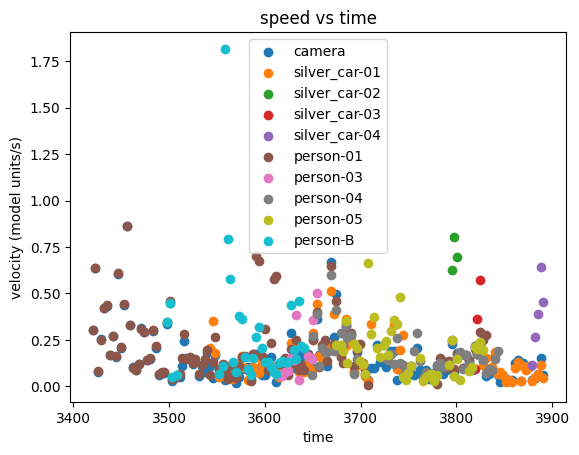

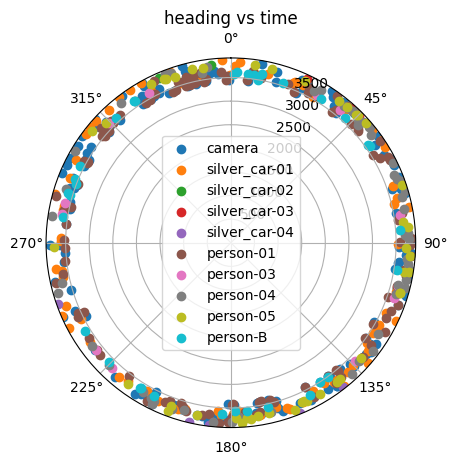

In [72]:
##3D Graphing and analysis METRIC OR NOT - per recon
# Speed/direction and meetings are both distance maths, so they run inside one recon's
# space. A requested pair is only measurable in a recon that actually saw both of them;
# pairs that split across two recons are reported as skipped rather than silently wrong.
from Q_Metric_georeferencing import speed_direction, _speed_direction_single
from Q_subject_analysis import  meeting_calculator
from render_paper_edit import build_meeting_requests

meeting_pairs = build_meeting_requests(paper_edit_json_path)   # [["person-1","person-2"], ["person-1","camera"]]

for job in recon_jobs:
    subjects = job.get("subjects_real_pos") or job.get("subjects_positions") or {}
    job["group_metrics"] = speed_direction(
        {"camera": job["cam_poses_model"], **subjects}, fps)

    meetings = {}
    subjects_distance_to_camera = {}
    for A_dict_entry, B_dict_entry in meeting_pairs:
        B_is_camera = B_dict_entry == "camera"
        if A_dict_entry not in subjects or (not B_is_camera and B_dict_entry not in subjects):
            print(f"{job['beat_key']}: skipping {A_dict_entry} vs {B_dict_entry} "
                  f"-- not both present in this recon")
            continue
        A_real_dict = subjects[A_dict_entry]
        B_real_dict = job["cam_poses_model"] if B_is_camera else subjects[B_dict_entry]

        if B_is_camera:
            meeting_report, distance_series = meeting_calculator(
                A_real_dict, A_dict_entry, B_real_dict, B_dict_entry,
                B_is_camera=B_is_camera, return_series=True)
            subjects_distance_to_camera[A_dict_entry] = distance_series
        else:
            meeting_report = meeting_calculator(
                A_real_dict, A_dict_entry, B_real_dict, B_dict_entry,
                B_is_camera=B_is_camera)
        meetings[(A_dict_entry, B_dict_entry)] = meeting_report
    job["meetings"] = meetings
    job["subjects_distance_to_camera"] = subjects_distance_to_camera
    print(f"--- {job['beat_key']} {job['kind']} ---")
    print(meetings)

##TEMP TESTS

## this will be deleted

In [42]:
depth_intersection = False
if depth_intersection == True:
    #depth based intersections checker # TEMP
    #mask overlay sequence: person-1 (green) vs sword (magenta)
    from Two2D.W_video_editor import apply_mask_overlay, _load_mask_bool
    from A_Config import assets_dir, source_video_path
    from pathlib import Path
    import cv2
    A_slug, B_slug = "person-1", "the_large_sword-1"
    def _dirs(slug):
        e = analysis_2d_for_decisions[slug]
        return [Path(d) for d in (e.get("masks_dirs") or [e["masks_dir"]])]
    A_dir, B_dir = _dirs(A_slug)[0], _dirs(B_slug)[0]
    #sword is person 5
    B_dir = Path("/workspace/project/Data/304_met_multi_4/015_SAM3_masks/pipetest_01/person-3")   # the sword



    out_dir = assets_dir() / f"contact_check_{A_slug}_vs_{B_slug}"
    out_dir.mkdir(parents=True, exist_ok=True)

    frames = sorted(set(analysis_2d_for_decisions[A_slug]["Subject_frames_present"]) |
                    set(analysis_2d_for_decisions[B_slug]["Subject_frames_present"]))

    cap = cv2.VideoCapture(str(source_video_path()))
    for f in frames:
        cap.set(cv2.CAP_PROP_POS_FRAMES, f)
        ret, frame = cap.read()
        if not ret:
            continue
        for d, colour in ((A_dir, (0, 200, 0)), (B_dir, (200, 0, 200))):
            m = _load_mask_bool(d, f)
            if m is not None:
                frame = apply_mask_overlay(frame, m, color=colour)
        cv2.imwrite(str(out_dir / f"{f:04d}.png"), frame)
    cap.release()
    print(out_dir, len(frames), "frames")

# TOUCHING TEST
## Needs work  see PHYSICS - NEW FLAGS PLAN MULTI RECON 

In [43]:
# subject touching test
if depth_intersection == True:
    # Manual/WIP cell -- there's no rule yet for which recon a contact test belongs to,
    # so pick the job by hand (see the RECON JOBS cell for what's available).
    from Q_subject_analysis import contact_frames
    job = recon_jobs[0]
    res = contact_frames(job["recon"], A_dir, B_dir)

    r = res[386]          # your contact frame
    plt.plot(list(r["A_profile"]), list(r["A_profile"].values()), "o-", label="A")
    plt.plot(list(r["B_profile"]), list(r["B_profile"].values()), "o-", label="B")
    plt.xlabel("depthels from seam"); plt.ylabel("depth"); plt.legend()
    print(r["depth_gap"], r["fit_resid"], r["contact"])


# PRODUCER 2

In [44]:
#FLAGS dict and 'producer dict
print(flags)
MENU_KEYS = {"TRACKING","RECON_CAM_POSES", "RECON_3D",
                          "GOOGLE_MAP", "BEV_MAP" , "PROJECTION", "MASK_OVERLAYS", "MULTICAM"}
producer_flags = {k: v for k, v in flags.items() if k in MENU_KEYS}

{'VID_TO_TEXT': True, 'TRACKING': True, 'FRAME_SELECTION': True, 'RECON_CAM_POSES': True, 'RECON_3D': False, 'GOOGLE_MAP': False, 'BEV_MAP': True, 'PROJECTION': False, 'MAKE_MOVIE': False, 'MAKE_MOVIE_CUTS': False, 'MASK_OVERLAYS': False, 'PHYSICS_OVERLAYS': False, 'MULTICAM': False}


In [45]:
print(paper_edit_json_path)

/workspace/project/Data/205_copper_05/012_agent_p_output/ablation_01/205_copper_05_ablation_01_1_draft.json


In [46]:
#find the cut points
import Two2D.W_video_editor
Two2D.W_video_editor.find_all_cut_points(video_path, analysis_2d_for_decisions, paper_edit_json_path)

off 128.064646


PosixPath('/workspace/project/Data/205_copper_05/012_agent_p_output/ablation_01/205_copper_05_ablation_01_1_draft.json')

In [47]:
pprint(analysis_2d_for_decisions)

{'GPS_signal': 'no',
 'person-01': {'Subject_frames_present': [3330,
                                          3331,
                                          3332,
                                          3333,
                                          3334,
                                          3335,
                                          3336,
                                          3337,
                                          3338,
                                          3339,
                                          3340,
                                          3341,
                                          3342,
                                          3343,
                                          3344,
                                          3345,
                                          3346,
                                          3347,
                                          3348,
                                          3349,
                   

In [48]:
#run producer again
from producer_agent_execution import run_producer_agent, build_producer_prompt_revision

prompt = build_producer_prompt_revision(Question, analysis_2d_for_decisions, producer_flags, paper_edit_json_path)
paper_edit_json_path = run_producer_agent(prompt)

[16:26:36 +  0.00s] run_producer_agent: start
[16:26:36 +  0.00s] thread: start
[16:26:36 +  0.00s] event loop: created
[16:26:36 +  0.00s] query: start
[16:26:45 +  9.13s] turn 1 usage (claude-opus-5): in=2 out=3 cache_write=11103 cache_read=10928
[16:26:45 +  9.13s] turn 1 content blocks: ['ThinkingBlock']
[16:26:45 +  9.13s] thinking:
I need to fix the ordering of beats 7 and 8 since beat-07's frames actually come before beat-06 chronologically, so I'm reordering them. Since beat-08 overlaps with beat-06's frame range, I'm merging them into a single aftermath segment, then sequencing beat-07's soundbite first followed by that merged section, before moving on to tracking person-B in beat-05's map.

For beat-05, person-B tracks fine and the silver car reappears but stays plausible. Beats 2/3 and 3/4 have minor frame overlaps that aren't worth merging — I'll just flag them as judgment calls and move forward with writing the file.
[16:27:07 + 31.03s] turn 2 usage (claude-opus-5): in=2 o

In [49]:
#prevent proucer mistakes
from render_paper_edit import match_revision_beat_ids
match_revision_beat_ids()


{'case_name': '205_copper_05', 'brief': 'Make a video summary of this video', 'beats': [{'archetype': 'ESTABLISHER', 'order': 1, 'beat_id': ['beat-01'], 'segment_type': 'real', 'duration_seconds': 8, 'source': 'Bodycam POV, car interior, officer driving through residential streets (00:00-00:30 per DESCRIPTION)', 'start_frame': 0, 'end_frame': 375, 'lead_in_seconds': None, 'search_window_start_seconds': 0, 'search_window_end_seconds': 12, 'requested_flags': None, 'quote': None, 'rationale': 'Pre-incident normal state; auto-selected range returned and matches requested length.', 'rejected_alternative': None, 'flag': None, 'tracked_subject': None}, {'archetype': 'EVENT_TRIGGER', 'order': 2, 'beat_id': ['beat-02'], 'segment_type': 'real', 'duration_seconds': 6, 'source': 'Bodycam POV, 01:52-01:58 — vehicle slows and stops, officer opens door on street roadway', 'start_frame': 3281, 'end_frame': 3571, 'lead_in_seconds': None, 'search_window_start_seconds': 110, 'search_window_end_seconds': 

In [50]:
#find the cut points again
import Two2D.W_video_editor
Two2D.W_video_editor.find_all_cut_points(video_path, analysis_2d_for_decisions, paper_edit_json_path)

off 128.064646


PosixPath('/workspace/project/Data/205_copper_05/012_agent_p_output/ablation_01/205_copper_05_ablation_01_1_revision.json')

# Rendering

In [51]:
print(analysis_2d_for_decisions)

{'GPS_signal': 'no', 'silver_car-01': {'Subject_frames_present': [3544, 3545, 3546, 3547, 3548, 3549, 3550, 3551, 3552, 3553, 3556, 3557, 3558, 3559, 3560, 3561, 3562, 3563, 3564, 3565, 3566, 3567, 3568, 3569, 3570, 3571, 3572, 3573, 3574, 3575, 3576, 3577, 3578, 3579, 3580, 3581, 3582, 3583, 3584, 3585, 3586, 3587, 3588, 3589, 3590, 3591, 3592, 3593, 3594, 3595, 3596, 3597, 3598, 3599, 3600, 3601, 3602, 3603, 3604, 3605, 3606, 3607, 3608, 3609, 3610, 3611, 3612, 3613, 3614, 3615, 3616, 3617, 3618, 3619, 3620, 3621, 3622, 3623, 3624, 3625, 3626, 3627, 3628, 3629, 3630, 3631, 3632, 3633, 3635, 3636, 3637, 3638, 3639, 3640, 3641, 3642, 3644, 3645, 3646, 3647, 3648, 3649, 3650, 3651, 3655, 3656, 3657, 3658, 3659, 3660, 3663, 3664, 3665, 3666, 3673, 3674, 3675, 3676, 3677, 3678, 3679, 3680, 3681, 3682, 3683, 3684, 3685, 3686, 3687, 3688, 3689, 3690, 3691, 3692, 3693, 3694, 3695, 3696, 3697, 3698, 3699, 3700, 3701, 3702, 3703, 3704, 3705, 3741, 3834, 3835, 3836, 3837, 3838, 3839, 3840, 3841

## Projection

In [52]:
for job in recon_jobs:
    print(job["beat_key"], job["kind"], job["flag"], job["start_frame"], job["end_frame"])



beat-05 MAP RECON_CAM_POSES 3417 3896


In [53]:
from Q_subject_analysis import find_mask_centroids_in_model_space, auto_camera_position, look_at_rotation, subject_oriented_box
from P_projection_mapping import solve_auto_camera_extrinsic,  projection_mapping_sequence, mean_camera_extrinsic
from Two2D.B_video_processing import available_frames
from run_models.A_ROBOFLOW_SAM3 import _slugify_subject
#dual setup
# every knob visible and tweakable right here -- raw VGGT-O model units, no metric/GPS needed
margin                  = 0.2   #fraction of to the full-mask-point box, on every side
extra_distance_margin   = 0.0
   # extra pull-back so off-center corners don't clip
conf_percentile         = 30  # drop masked pixels below this depth-confidence percentile
                               # (guards against a misprojected frame blowing the box out --
sr = 3 #splat radius

#load up paper edit beats
_revised_beats_by_key = {
    b["beat_id"][0]: b
    for b in json.loads(paper_edit_path(mode="revision").read_text(encoding="utf-8"))["beats"]
}
#check for projection beats
projection_beats = [b for b in _revised_beats_by_key.values() if b["archetype"] == "PROJECTION"]
if not projection_beats:
    print("no PROJECTION beats in this revision")
else:
#print(_revised_beats_by_key)
#Use this to project every frame in each recon
    for job in jobs_of(kind="EVENT"):
        #print("KEYS",job.keys())
        #-------positions/masks only really need one, but making a mess at first---------------
        beat = _revised_beats_by_key.get(job["beat_key"], job["beat"])#open up the paper edit beat

        wanted = {
            entry["gem_person_id"] if isinstance(entry, dict) else _slugify_subject(entry)
            for entry in (beat.get("tracked_subject") or []) #find tracked subjets in the paper edit
        }
        print("Subjects to set camera",wanted)

        beat_name = job["beat_ids"][0]   # same as W_video_editor's beat_name = beat["beat_id"][0]

        masks_dirs = list(dict.fromkeys(
            d
            for key, entry in (analysis_2d_for_decisions or {}).items()
            if isinstance(entry, dict)
            and job["beat_key"] in (entry.get("beat_ids") or [])
            and (key in wanted or key.rsplit("-", 1)[0] in wanted)
            for d in ([entry["masks_dir"]] if entry.get("masks_dir") else entry.get("masks_dirs") or [])
        ))
        print(masks_dirs)
        extrinsics_np = job["recon"].preds["extrinsic"].cpu().numpy()
        conf_vggt     = job["recon"].preds["depth_conf"].cpu().numpy()
        ct_vggt  = np.percentile(conf_vggt, conf_percentile)

        # Tracking can come back with nothing: no masks_dir for the wanted subject at all,
        # or dirs whose masks are empty on every frame. Collect whatever we do get, per
        # mask dir, and decide afterwards whether there's enough to aim a camera with.
        mask_points_all, weights_all = [], []
        for masks_dir in masks_dirs:
            print(masks_dir)
            subject_cenroids_model, frame_keys, _ ,_ ,weights, mask_points = find_mask_centroids_in_model_space(
            job["recon"],masks_dir, autocam=True,
            conf_thresh=ct_vggt,
            )
            if mask_points is not None and len(mask_points):
                mask_points_all.append(np.asarray(mask_points))
            weights_all.append(np.asarray(weights, dtype=float))
        #final collection -- one point cloud and one per-frame weight vector across all subjects
        mask_points_total = np.concatenate(mask_points_all, axis=0) if mask_points_all else np.empty((0, 3))
        weights_total = np.max(np.stack(weights_all), axis=0) if weights_all else np.zeros(len(extrinsics_np))
        # enough to aim at a subject? need real (non-NaN) points AND at least one frame the
        # subject was actually visible in -- both are what the look-at solve depends on.
        tracked_ok = (
            (~np.isnan(mask_points_total).any(axis=1)).sum() >= 2
            and np.any(weights_total > 0)
        )

        #------get frames-----------
        job["extra_indices"] = available_frames(job["frames_dir"], FRAME_NAME_FMT)
        print(f"{job['beat_key']} {job['kind']}: {len(job['extra_indices'])} frames in recon")
        extra_indices = job["extra_indices"]

        print(extra_indices)

        if tracked_ok:
            # Position from the weighted-average of where the real cameras stood (a robust
            # signal),
            down_refs = extrinsics_np[:, 1, :3]   # each frame's own down axis, model space
            up_model = -(down_refs[weights_total > 0] * weights_total[weights_total > 0, None]).sum(axis=0)
            up_model /= np.linalg.norm(up_model)

            C_avg = auto_camera_position(extrinsics_np, weights_total)
            # One oriented box, used for BOTH the framing solve and the debug draw. Fitting the
            # raw points instead let the box's corners (extreme in all 3 axes at once) stick out
            # past every real point and shoot off-screen.
            obb_corners = subject_oriented_box(mask_points_total, margin = margin,percentile=95)
            box_center = obb_corners.mean(axis=0)
            R_auto_c2w = look_at_rotation(C_avg, box_center, up_model)

            new_view = solve_auto_camera_extrinsic(
                obb_corners, box_center, R_auto_c2w,
                job["recon"].preds["intrinsic"][0].cpu().numpy(),
                job["recon"].preds["depth"].shape[1:],
                extra_distance_margin=extra_distance_margin,
                dtype=job["recon"].preds["extrinsic"].dtype,
            )

            print("R_auto orthonormal check:", np.allclose(R_auto_c2w @ R_auto_c2w.T, np.eye(3), atol=1e-4), "det:", np.linalg.det(R_auto_c2w))
            print("C_avg (model units):", C_avg, "box_center:", box_center)
            print("weights: min/max/mean/#nonzero:", weights_total.min(), weights_total.max(), weights_total.mean(), (weights_total > 0).sum())
        else:
            # FALLBACK -- tracking gave us nothing to aim at, so frame on the mean of the
            # real cameras instead of on the subject. The shot still gets made; it's just
            # "where the shoot was pointed", not "where the subject was".
            print(f"{job['beat_key']}: no usable subject masks "
                  f"({len(masks_dirs)} mask dir(s), {len(mask_points_total)} points) "
                  "-- falling back to the mean camera pose")
            new_view = mean_camera_extrinsic(
                extrinsics_np,
                pull_back=extra_distance_margin,
                dtype=job["recon"].preds["extrinsic"].dtype,
            )
        #---------------------------------------------------------------------------------------------

        #new_view = recon.preds["extrinsic"][-1]
        _ = projection_mapping_sequence(
            recon=job["recon"],
            extra_indices=extra_indices,  # one output frame per source frame, default naming
            #extra_indices= [282],  # one output frame per source frame, default naming
            new_view=new_view,
            confidence_threshold=ct_vggt,
            #masks_dir = masks_dir,
            use_lowres_images=False,
            splat_radius = sr,
            frame_rate = fps,
            out_dir_name= f"projection_frames_{job['beat_key']}"


        )
        #---------------------------------------------------------------------------------------------------------------------------------------


no PROJECTION beats in this revision


## Mapping

In [54]:
#make animated map -- one map per GOOGLE_MAP beat. Each writes its own image sequence
# to assets/map_frames_<beat_key> (the standard hand-off to the editor); gif/mp4 are
# optional extra exports of the same frames. Duration comes from the beat we pass in,
# so two MAP beats get two different-length animations instead of sharing one.
flags["GOOGLE_MAP"] = True
if flags["GOOGLE_MAP"] == True:
    import Rendering.R_map_animator
    from render_paper_edit import paper_edit_path, select_subjects

    _default_palette = ["#e74c3c", "#2ecc71", "#f39c12", "#9b59b6", "#1abc9c", "#e67e22"]

    # Revision pass can still edit tracked_subject after recon_jobs was built (cell 28
    # read the draft) -- re-read the revised paper edit here, same fix as the
    # BEV_trace_overlay cell, so subjects_latlon only shows what THIS beat actually asked for.
    _revised_beats_by_key = {
        b["beat_id"][0]: b
        for b in json.loads(paper_edit_path(mode="revision").read_text(encoding="utf-8"))["beats"]
    }

    for job in jobs_of(archetype="MAP", flag="GOOGLE_MAP"):
        beat = _revised_beats_by_key.get(job["beat_key"], job["beat"])
        subject_traces = [
            {"coords": latlons, "trail_color": _default_palette[i % len(_default_palette)]}
            for i, latlons in enumerate(
                select_subjects(job.get("subjects_latlon", {}), beat).values())
        ]
        Rendering.R_map_animator.main(
            traces = [
                {"coords": job["cam_latlons"], "trail_color": "#3498db"},     #cameras
                *subject_traces,
            ],
            api_key = api_key,
            beat    = beat,
            gif = True,
            mp4 = None,
        )
else:
     print("Cell disabled")


In [55]:
#get times of day into the report
from C_CSV_report import attach_times_of_day
report = attach_times_of_day(video_path, 30.07)

In [56]:
#BEV SETUP - the frames each recon actually holds, per job
from P_projection_mapping import projection_mapping_sequence, BEV_tile_render_PM
from AA_cam_pose_sweeps import _render_bev_tiles

from Two2D.B_video_processing import available_frames

#Use this to project every frame in each recon
for job in recon_jobs:
    job["extra_indices"] = available_frames(job["frames_dir"], FRAME_NAME_FMT)
    print(f"{job['beat_key']} {job['kind']}: {len(job['extra_indices'])} frames in recon")


beat-05 MAP: 160 frames in recon


In [67]:
#BEV HI RES - one BEV still per BEV_MAP beat
#BEV projection mapping of subject to a selected view
# BEV_tile_render_PM's default out_path is asset_name-based (one file for the whole
# case), so pass a beat-keyed path in. That also skips its own add_to_asset_list, so
# the beat-keyed asset row is logged here instead.
from A_Config import assets_dir, asset_name, to_report_path
from C_CSV_report import add_to_asset_list

for job in jobs_of(archetype="MAP", flag="BEV_MAP"):
    out_path = assets_dir() / f"{asset_name()}_BEV_tile_render_PM_{job['beat_key']}.png"
    BEV, job["new_view"], job["ortho_params"], job["BEV_path"] = BEV_tile_render_PM(
        job["recon"],
        job["extra_indices"],
        masks_dir = None,
        splat_radius = 1,
        confidence_threshold=np.percentile(conf, 60),
        margin_frac = 0.05,
        out_path = out_path,
    )
    add_to_asset_list({f"BEV_tile_render_PM_{job['beat_key']}": to_report_path(job["BEV_path"])})
    print(f"{job['beat_key']}: {job['BEV_path']}")


min depth tensor(0.0036, device='cuda:0')
torch.Size([16908284, 3])
mins, maxes and ranges -0.3856177404522896 0.23075608164072037 0.61637382209301 -0.19295071810483932 0.4169514998793602 0.6099022179841995
scale - original 6706.525307493371
beat-05: /workspace/project/Data/205_copper_05/090_assets/ablation_01/205_copper_05_ablation_01_BEV_tile_render_PM_beat-05.png


In [68]:
subject_positions = job.get("subjects_positions") or {},
print(job['beat_key'])
pprint(subject_positions)

beat-05
({'person-01': {3417: array([-0.00353338,  0.00407316,  0.00967458]),
                3420: array([-0.01310745, -0.00628556,  0.04715961]),
                3423: array([ 0.00741622,  0.00865439, -0.05011446]),
                3426: array([ 0.01690077,  0.01723887, -0.07470584]),
                3429: array([ 0.00686174,  0.01562103, -0.06470349]),
                3432: array([ 0.00020003,  0.00406953, -0.02987631]),
                3435: array([ 0.02259898,  0.02569245, -0.1478763 ]),
                3438: array([ 0.00120618,  0.01773597, -0.11615147]),
                3441: array([ 0.01059738,  0.0258162 , -0.11628036]),
                3444: array([ 0.02452223,  0.03128613, -0.1626243 ]),
                3447: array([-0.01767217,  0.01831374, -0.13004184]),
                3450: array([-0.00796365,  0.00754939, -0.04768774]),
                3453: array([-0.02856102,  0.01740905, -0.08908193]),
                3456: array([-0.01063066, -0.00907845,  0.03951372]),
            

In [ ]:
#TRACE OVERLAY Animate the camera (position + heading frustum) over the BEV_tile_render_PM still.
#One animation per BEV_MAP beat, each over its own BEV still. n_frames comes from the beat
#we pass in (duration_seconds * fps), and frames land in bev_trace_frames_<beat_key>.
from P_trace_overlayer import BEV_trace_overlay
from render_paper_edit import paper_edit_path, select_subjects

#load up papter edit beats
_revised_beats_by_key = {
    b["beat_id"][0]: b
    for b in json.loads(paper_edit_path(mode="revision").read_text(encoding="utf-8"))["beats"]
}

for job in jobs_of(archetype="MAP", flag="BEV_MAP"):
    all_positions = job.get("subjects_real_pos") or job.get("subjects_positions") or {}
    beat = _revised_beats_by_key.get(job["beat_key"], job["beat"])#open up the paper edit beat

    # Only the subjects THIS beat's own (revised) tracked_subject named in the
    # paper edit -- not every track the recon happens to have positions for
    # (generic person-09..19 etc. that were never asked for on this beat).
    subject_positions = select_subjects(all_positions, beat)
    BEV_trace_overlay(
        job["recon"],
        job["extra_indices"],
        job["new_view"],
        job["ortho_params"],
        subject_positions = subject_positions,
        bev_png_path      = job["BEV_path"],
        beat              = beat,
    )


frame 0000 t_frac=0.0000 [camera] virtual_frame=3417.0 pos_px=(682.9, 738.3)
frame 0001 t_frac=0.0042 [camera] virtual_frame=3419.0 pos_px=(672.0, 693.5)
frame 0002 t_frac=0.0084 [camera] virtual_frame=3421.0 pos_px=(678.3, 729.0)
frame 0003 t_frac=0.0126 [camera] virtual_frame=3423.0 pos_px=(701.7, 843.5)
frame 0004 t_frac=0.0168 [camera] virtual_frame=3425.0 pos_px=(712.3, 871.9)
frame 0005 t_frac=0.0210 [camera] virtual_frame=3427.0 pos_px=(711.9, 879.3)
frame 0006 t_frac=0.0252 [camera] virtual_frame=3429.0 pos_px=(701.0, 866.1)
frame 0007 t_frac=0.0294 [camera] virtual_frame=3431.0 pos_px=(689.5, 824.8)
frame 0008 t_frac=0.0336 [camera] virtual_frame=3433.0 pos_px=(698.1, 876.5)
frame 0009 t_frac=0.0378 [camera] virtual_frame=3435.0 pos_px=(724.7, 1012.2)
frame 0010 t_frac=0.0420 [camera] virtual_frame=3437.0 pos_px=(699.1, 974.5)
frame 0011 t_frac=0.0462 [camera] virtual_frame=3439.0 pos_px=(693.0, 956.8)
frame 0012 t_frac=0.0504 [camera] virtual_frame=3441.1 pos_px=(704.8, 958.7

: 

In [60]:
import torch
print(torch.is_autocast_enabled())


False


In [61]:
#Make the edited multimedia movie

import Two2D.W_video_editor
 
Two2D.W_video_editor.assemble_paper_edit(video_path,analysis_2d_for_decisions, recon_jobs=recon_jobs)

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

/workspace/project/Data/205_copper_05/090_assets/ablation_01/205_copper_05_ablation_01_1_rough_cut.mp4


[out#0/mp4 @ 0x564cf7741300] video:39284KiB audio:963KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.233507%
frame= 2724 fps= 99 q=-1.0 Lsize=   40341KiB time=00:01:30.82 bitrate=3638.6kbits/s speed= 3.3x    
[libx264 @ 0x564cf77ae840] frame I:16    Avg QP:21.64  size: 90935
[libx264 @ 0x564cf77ae840] frame P:1348  Avg QP:25.03  size: 22287
[libx264 @ 0x564cf77ae840] frame B:1360  Avg QP:27.96  size:  6418
[libx264 @ 0x564cf77ae840] consecutive B-frames: 25.8% 17.5% 15.6% 41.0%
[libx264 @ 0x564cf77ae840] mb I  I16..4: 17.7% 63.8% 18.5%
[libx264 @ 0x564cf77ae840] mb P  I16..4:  7.9% 16.1%  2.2%  P16..4: 36.4% 12.2%  5.8%  0.0%  0.0%    skip:19.3%
[libx264 @ 0x564cf77ae840] mb B  I16..4:  1.5%  2.6%  0.5%  B16..8: 40.5%  5.5%  1.0%  direct: 1.4%  skip:47.1%  L0:51.8% L1:40.9% BI: 7.2%
[libx264 @ 0x564cf77ae840] 8x8 transform intra:61.0% inter:60.2%
[libx264 @ 0x564cf77ae840] coded y,uvDC,uvAC intra: 37.9% 46.7% 5.2% inter: 15.6% 12.0% 0.3%
[libx264 @ 0x564cf77

PosixPath('/workspace/project/Data/205_copper_05/090_assets/ablation_01/205_copper_05_ablation_01_1_rough_cut.mp4')

In [62]:
print(PASS)

1


In [63]:
from V_text_summary import gemini_final_report, gemini_cache_video
vid_path = assets_dir() / f"{asset_name()}_{PASS}_rough_cut.mp4"
cache =  gemini_cache_video(vid_path, assets_dir(), ttl="6000s")
gemini_final_report()

On June 5, 2022, at approximately 2:02 PM, a critical police shooting incident occurred on a city street, as recorded by an officer's body-worn camera.

The main subject, designated as person-B, was involved in the event from 13:04:50 to 13:05:04. During this duration, the subject moved a net distance of 0.11323522653035906 model units at a heading of 329.42005356860557 degrees.

The subject is seen near a handgun on the asphalt street, surrounded by blood. An assisting officer interacts directly with the subject, applying a tourniquet to their heavily bleeding arm.

Other officers and dispatchers communicate about the subject over the radio, calling out medical emergency status updates. Additionally, green highlights and tracking masks are visible in the footage, specifically focusing on a silver car during the initial encounter.
**00:23** [Officer on foot]: Get out of the car! Don't move!

**00:30** [Injured Officer]: (groans) Ah! (groans) Ah! (groans) Ah!

**00:36** [Injured Officer

In [64]:

timer_end()


[default] 1027.13s


1027.133075684309

In [ ]:
# Cell — Populate PowerPoint from CSV
import importlib

import W_populate_pptx
importlib.reload(W_populate_pptx)
from W_populate_pptx import populate



report_template = project_root / "src" / "Powerpoint" / f"{ppt_template}.pptx"
ppt_assets   = case_dir / "090_Assets"
ppt_csv      = ppt_assets / f"{case_name}.csv"
ppt_output   = case_dir / "100_Powerpoint" / f"{case_name}.pptx"


populate(str(report_template))

NameError: name 'ppt_template' is not defined

(viser) Connection opened (0, 1 total), 21 persistent messages

(viser) Connection opened (1, 2 total), 21 persistent messages

(viser) Connection closed (0, 1 total)

(viser) Connection closed (1, 0 total)